In [2]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
CSV_DIR = Path("csv")
OUT_DIR = Path("paper_figures")
OUT_DIR.mkdir(exist_ok=True)

# Rename W&B run names to paper labels.
# Your PPO run appears as "skilled-sweep-15" in the CSV export.
ALG_RENAME = {
    "dqn": "DQN",
    "td3": "TD3",
    "sac": "SAC",
    "a2c": "A2C",
    "ppo": "PPO",
    "skilled-sweep-15": "PPO",
}

ALG_ORDER = ["DQN", "TD3", "SAC", "A2C", "PPO"]

# No extra smoothing by default because train/reward_mean and train/success_rate
# are already rolling metrics from the training callback.
EXTRA_ROLLING_WINDOW = 1

In [5]:
def canonical_algorithm(raw_name: str) -> str:
    raw = raw_name.strip()
    return ALG_RENAME.get(raw.lower(), raw.upper())


def detect_metric_columns(df: pd.DataFrame):
    """
    Find columns like:
        "dqn - train/reward_mean"
        "td3 - train/success_rate"

    Ignores W&B export helper columns:
        __MIN, __MAX, _step
    """
    detected = []

    for col in df.columns:
        if "__MIN" in col or "__MAX" in col or col.endswith("_step") or " - _step" in col:
            continue

        match = re.match(r"(.+?)\s+-\s+train/(reward_mean|success_rate)$", col)
        if match:
            raw_alg = match.group(1).strip()
            metric = match.group(2).strip()
            detected.append((col, canonical_algorithm(raw_alg), metric))

    return detected


def load_wandb_csv_exports(csv_dir: Path) -> pd.DataFrame:
    rows = []

    for path in sorted(csv_dir.glob("*.csv")):
        df = pd.read_csv(path)

        if "train/episode" in df.columns:
            x_col = "train/episode"
        elif "Step" in df.columns:
            x_col = "Step"
        else:
            print(f"Skipping {path.name}: no Step or train/episode column.")
            continue

        detected = detect_metric_columns(df)

        if not detected:
            print(f"Skipping {path.name}: no recognized train metric column.")
            continue

        for y_col, alg, metric in detected:
            tmp = df[[x_col, y_col]].copy()
            tmp.columns = ["episode", "value"]
            tmp["algorithm"] = alg
            tmp["metric"] = metric
            tmp["source_file"] = path.name

            tmp["episode"] = pd.to_numeric(tmp["episode"], errors="coerce")
            tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
            tmp = tmp.dropna(subset=["episode", "value"])

            rows.append(tmp)

    if not rows:
        raise RuntimeError(f"No valid W&B CSV exports found in {csv_dir.resolve()}")

    data = pd.concat(rows, ignore_index=True)
    data["episode"] = data["episode"].astype(int)

    return data


data = load_wandb_csv_exports(CSV_DIR)

print("Detected data:")
display(
    data.groupby(["algorithm", "metric"])["episode"]
    .agg(["min", "max", "count"])
    .reset_index()
)

Skipping LimoCrash.csv: no Step or train/episode column.
Skipping LimoCrash004.csv: no Step or train/episode column.
Detected data:


,algorithm,metric,min,max,count
0,A2C,reward_mean,1,2000,2000
1,A2C,success_rate,1,2000,2000
2,AVID-BUTTERFLY-1822,reward_mean,1,2000,2000
3,AVID-BUTTERFLY-1822,success_rate,1,2000,2000
4,BLOOMING-SWEEP-15,reward_mean,1,2000,2000
5,BLOOMING-SWEEP-15,success_rate,1,2000,2000
6,BREEZY-SWEEP-19,reward_mean,1,2000,2000
7,BREEZY-SWEEP-19,success_rate,1,2000,2000
8,CLEAN-SWEEP-4,reward_mean,1,2000,2000
9,CLEAN-SWEEP-4,success_rate,1,2000,2000


In [6]:
def aggregate_for_plot(data: pd.DataFrame) -> pd.DataFrame:
    """
    If there are duplicate rows for the same algorithm/metric/episode,
    average them. This makes the code safe if you later add multi-seed exports.
    """
    agg = (
        data.groupby(["algorithm", "metric", "episode"], as_index=False)
        .agg(value=("value", "mean"))
    )

    if EXTRA_ROLLING_WINDOW > 1:
        agg = agg.sort_values(["algorithm", "metric", "episode"])
        agg["value"] = (
            agg.groupby(["algorithm", "metric"])["value"]
            .transform(lambda s: s.rolling(EXTRA_ROLLING_WINDOW, min_periods=1).mean())
        )

    return agg


plot_data = aggregate_for_plot(data)

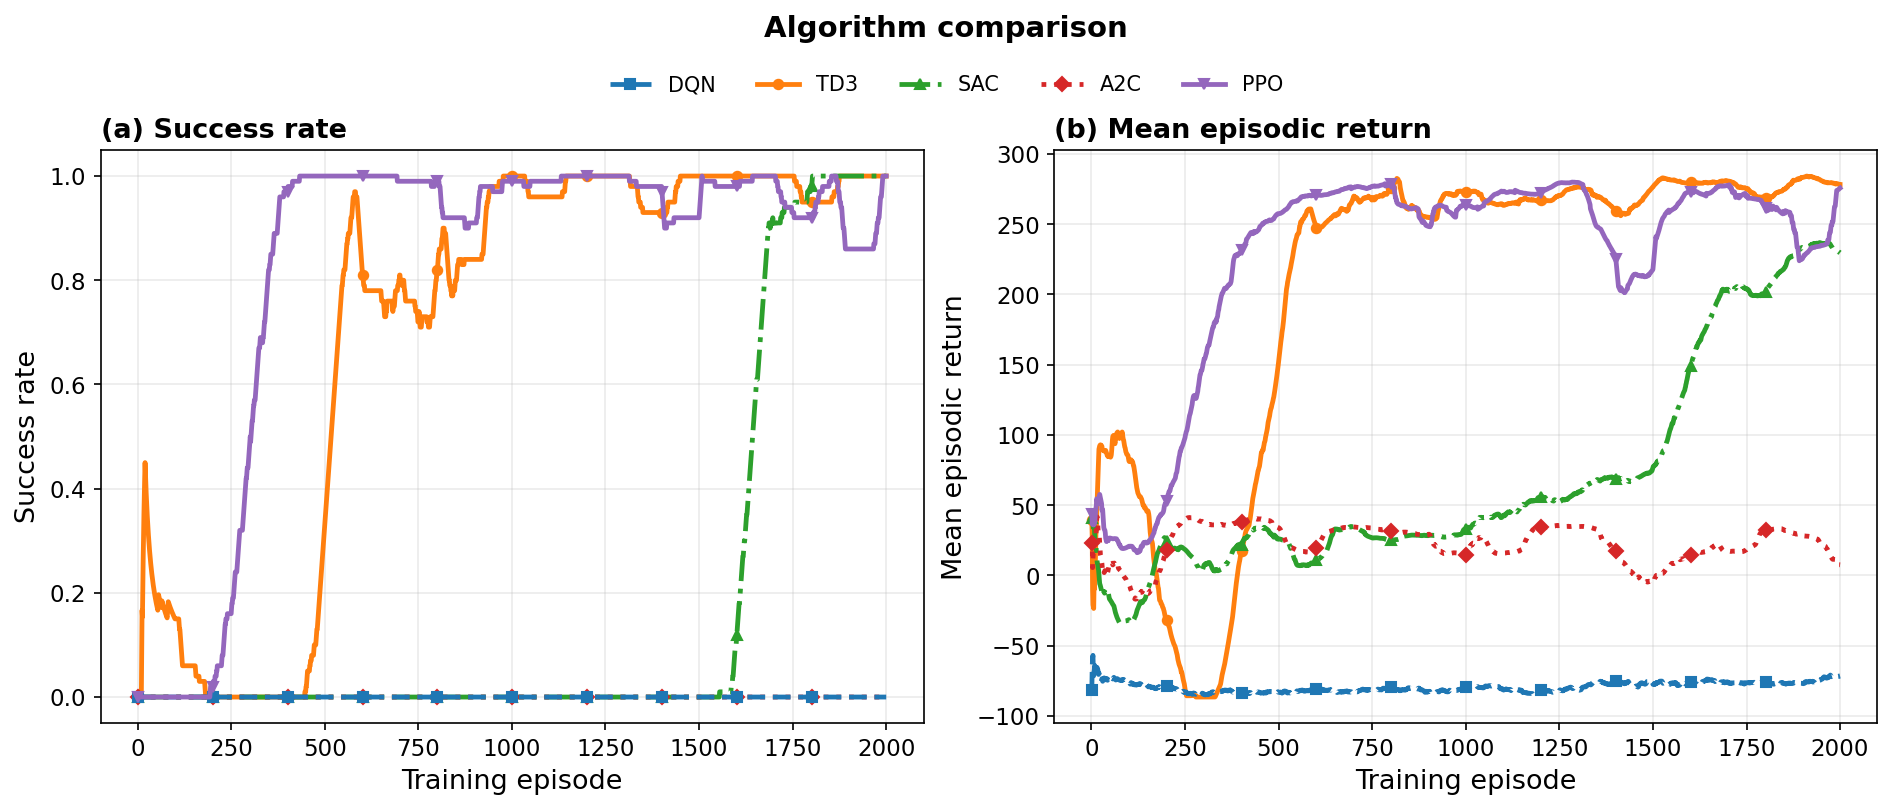

In [7]:
# Publication-style defaults
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2.3,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Line styles help distinguish methods even in grayscale.
LINE_STYLES = {
    "DQN": {"linestyle": "--", "marker": "s", "markevery": 200, "markersize": 4.5, "zorder": 5},
    "TD3": {"linestyle": "-",  "marker": "o", "markevery": 200, "markersize": 4.5, "zorder": 4},
    "SAC": {"linestyle": "-.", "marker": "^", "markevery": 200, "markersize": 4.5, "zorder": 4},
    "A2C": {"linestyle": ":",  "marker": "D", "markevery": 200, "markersize": 4.5, "zorder": 4},
    "PPO": {"linestyle": "-",  "marker": "v", "markevery": 200, "markersize": 4.5, "zorder": 6},
}


def plot_metric(ax, metric_name, ylabel, panel_label):
    metric_df = plot_data[plot_data["metric"] == metric_name].copy()

    for alg in ALG_ORDER:
        alg_df = metric_df[metric_df["algorithm"] == alg].sort_values("episode")
        if alg_df.empty:
            continue

        style = LINE_STYLES.get(alg, {})
        ax.plot(
            alg_df["episode"],
            alg_df["value"],
            label=alg,
            **style
        )

    ax.set_xlabel("Training episode")
    ax.set_ylabel(ylabel)
    ax.set_title(panel_label, loc="left", fontweight="bold")
    ax.tick_params(axis="both", which="major")

    # Keeps zero-valued DQN success curves visible above the axis line.
    if metric_name == "success_rate":
        ax.set_ylim(-0.05, 1.05)
        ax.set_yticks(np.linspace(0, 1, 6))


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

plot_metric(
    axes[0],
    metric_name="success_rate",
    ylabel="Success rate",
    panel_label="(a) Success rate"
)

plot_metric(
    axes[1],
    metric_name="reward_mean",
    ylabel="Mean episodic return",
    panel_label="(b) Mean episodic return"
)

# One shared legend for consistent placement.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.08)
)

fig.suptitle("Algorithm comparison", y=1.14, fontsize=14, fontweight="bold")

fig.savefig(OUT_DIR / "fig_algorithm_comparison.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "fig_algorithm_comparison.png", bbox_inches="tight", dpi=600)

plt.show()

In [37]:
# ---------------------------------------------------------------------
# Hardware trajectory figure configuration
# ---------------------------------------------------------------------

# Uses CSV_DIR and OUT_DIR defined earlier in the notebook.
# Change TRAJECTORY_DIR to Path(".") if the CSV files are beside the notebook.
TRAJECTORY_DIR = CSV_DIR

CRASH_CSV = TRAJECTORY_DIR / "LimoCrash.csv"
CLEAN_CSV = TRAJECTORY_DIR / "LimoCrash004.csv"

# Zero-based measurement rows after the two Vicon metadata rows are removed.
# The ending row is exclusive, as with normal Python slicing.
CRASH_START_ROW = 380
CRASH_END_ROW = 2006

CLEAN_START_ROW = 7315
CLEAN_END_ROW = 9955

# Set to 1 to disable smoothing.
SMOOTH_WINDOW = 9

# Approximate number of symbols drawn along each moving trajectory.
N_TRAJECTORY_MARKERS = 8

# Reversed limits reproduce the orientation of the existing paper figure.
# The clean run extends farther in X than the original attack trajectory.
X_LIMITS = (0.35, -5.85)
Y_LIMITS = (1.70, -1.80)

# Approximate measured wall locations.
WALL_X = np.array([0.30, -5.85])
UPPER_WALL_Y = np.array([-1.00, -0.90])
LOWER_WALL_Y = np.array([0.90, 1.02])

OUTPUT_STEM = "fig_hardware_trajectory_comparison"

In [38]:
def load_vicon_xy(path: Path, rigid_body: str) -> pd.DataFrame:
    """
    Load X/Y position data for one Vicon rigid body.

    The CSV files contain:
        line 1: object names
        line 2: TX/TY/TZ labels
        line 3: units
        remaining lines: measurements

    Returned positions are converted from millimeters to meters.
    """

    if not path.exists():
        raise FileNotFoundError(f"Trajectory CSV not found: {path.resolve()}")

    # Retain the first line as the header while skipping the TX/TY/TZ
    # and units metadata rows.
    raw = pd.read_csv(path, skiprows=[1, 2])

    position_column = f"Position - {rigid_body}"

    if position_column not in raw.columns:
        available = [
            column for column in raw.columns
            if str(column).startswith("Position -")
        ]
        raise KeyError(
            f"{position_column!r} was not found in {path.name}. "
            f"Available position columns: {available}"
        )

    x_column_index = raw.columns.get_loc(position_column)
    y_column_index = x_column_index + 1

    data = pd.DataFrame({
        "row": np.arange(len(raw), dtype=int),
        "frame": pd.to_numeric(raw.iloc[:, 0], errors="coerce"),
        "x_m": pd.to_numeric(
            raw.iloc[:, x_column_index],
            errors="coerce"
        ) / 1000.0,
        "y_m": pd.to_numeric(
            raw.iloc[:, y_column_index],
            errors="coerce"
        ) / 1000.0,
    })

    return data.dropna(subset=["frame"]).reset_index(drop=True)


def select_trajectory_segment(
    data: pd.DataFrame,
    start_row: int,
    end_row: int | None,
    smooth_window: int = 1,
) -> pd.DataFrame:
    """
    Select [start_row, end_row) and generate optionally smoothed
    plotting coordinates.
    """

    if start_row < 0:
        raise ValueError("start_row must be zero or greater.")

    effective_end = len(data) if end_row is None else end_row

    if effective_end <= start_row:
        raise ValueError("end_row must be greater than start_row.")

    segment = data.loc[
        (data["row"] >= start_row) &
        (data["row"] < effective_end)
    ].copy()

    segment = segment.dropna(subset=["x_m", "y_m"])

    if segment.empty:
        raise ValueError(
            f"No valid position data exists between rows "
            f"{start_row} and {effective_end}."
        )

    window = max(1, int(smooth_window))

    segment["x_plot"] = (
        segment["x_m"]
        .rolling(window, center=True, min_periods=1)
        .mean()
    )

    segment["y_plot"] = (
        segment["y_m"]
        .rolling(window, center=True, min_periods=1)
        .mean()
    )

    return segment


# Load complete recordings.
crash_attacker_all = load_vicon_xy(CRASH_CSV, "Limo_02")
crash_target_all = load_vicon_xy(CRASH_CSV, "Limo_04")
clean_target_all = load_vicon_xy(CLEAN_CSV, "Limo_04")

# Apply the configurable row ranges.
crash_attacker = select_trajectory_segment(
    crash_attacker_all,
    CRASH_START_ROW,
    CRASH_END_ROW,
    SMOOTH_WINDOW,
)

crash_target = select_trajectory_segment(
    crash_target_all,
    CRASH_START_ROW,
    CRASH_END_ROW,
    SMOOTH_WINDOW,
)

clean_target = select_trajectory_segment(
    clean_target_all,
    CLEAN_START_ROW,
    CLEAN_END_ROW,
    SMOOTH_WINDOW,
)


def trajectory_summary(name: str, segment: pd.DataFrame) -> dict:
    start = segment.iloc[0]
    end = segment.iloc[-1]

    return {
        "trajectory": name,
        "start row": int(start["row"]),
        "end row": int(end["row"]),
        "samples": len(segment),
        "start X (m)": start["x_plot"],
        "start Y (m)": start["y_plot"],
        "end X (m)": end["x_plot"],
        "end Y (m)": end["y_plot"],
    }


segment_summary = pd.DataFrame([
    trajectory_summary("Attacker — attack run", crash_attacker),
    trajectory_summary("Target — attack run", crash_target),
    trajectory_summary("Target — clean run 004", clean_target),
])

display(segment_summary.round(3))

,trajectory,start row,end row,samples,start X (m),start Y (m),end X (m),end Y (m)
0,Attacker — attack run,380,2005,1626,-0.824,-0.865,-4.990,0.740
1,Target — attack run,380,2005,1626,0.087,0.030,-0.890,0.754
2,Target — clean run 004,7315,9954,2640,0.053,0.004,-5.004,-0.246


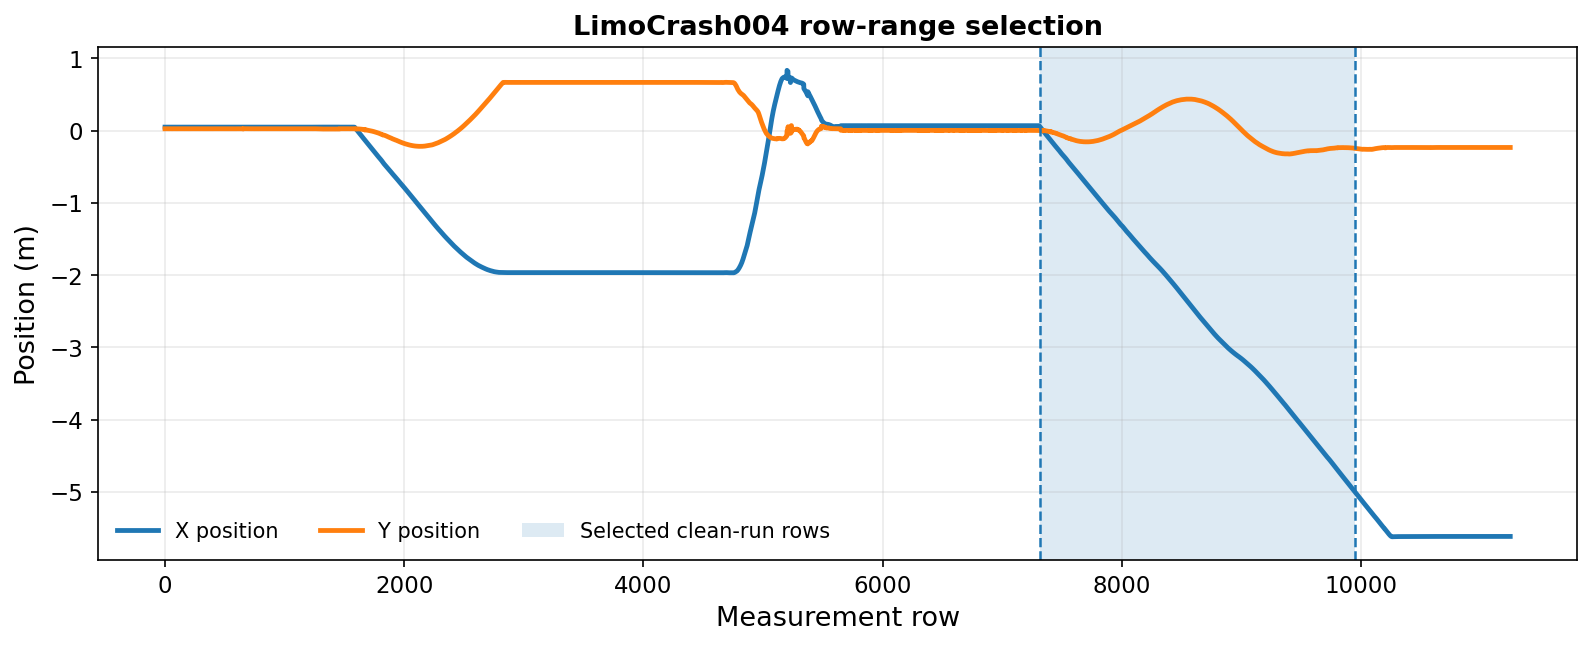

In [39]:
fig, ax = plt.subplots(figsize=(10.5, 4.2), constrained_layout=True)

ax.plot(
    clean_target_all["row"],
    clean_target_all["x_m"],
    label="X position",
)

ax.plot(
    clean_target_all["row"],
    clean_target_all["y_m"],
    label="Y position",
)

ax.axvspan(
    CLEAN_START_ROW,
    CLEAN_END_ROW,
    alpha=0.15,
    label="Selected clean-run rows",
)

ax.axvline(
    CLEAN_START_ROW,
    linestyle="--",
    linewidth=1.2,
)

ax.axvline(
    CLEAN_END_ROW,
    linestyle="--",
    linewidth=1.2,
)

ax.set_xlabel("Measurement row")
ax.set_ylabel("Position (m)")
ax.set_title("LimoCrash004 row-range selection", fontweight="bold")
ax.legend(frameon=False, ncol=3)

plt.show()

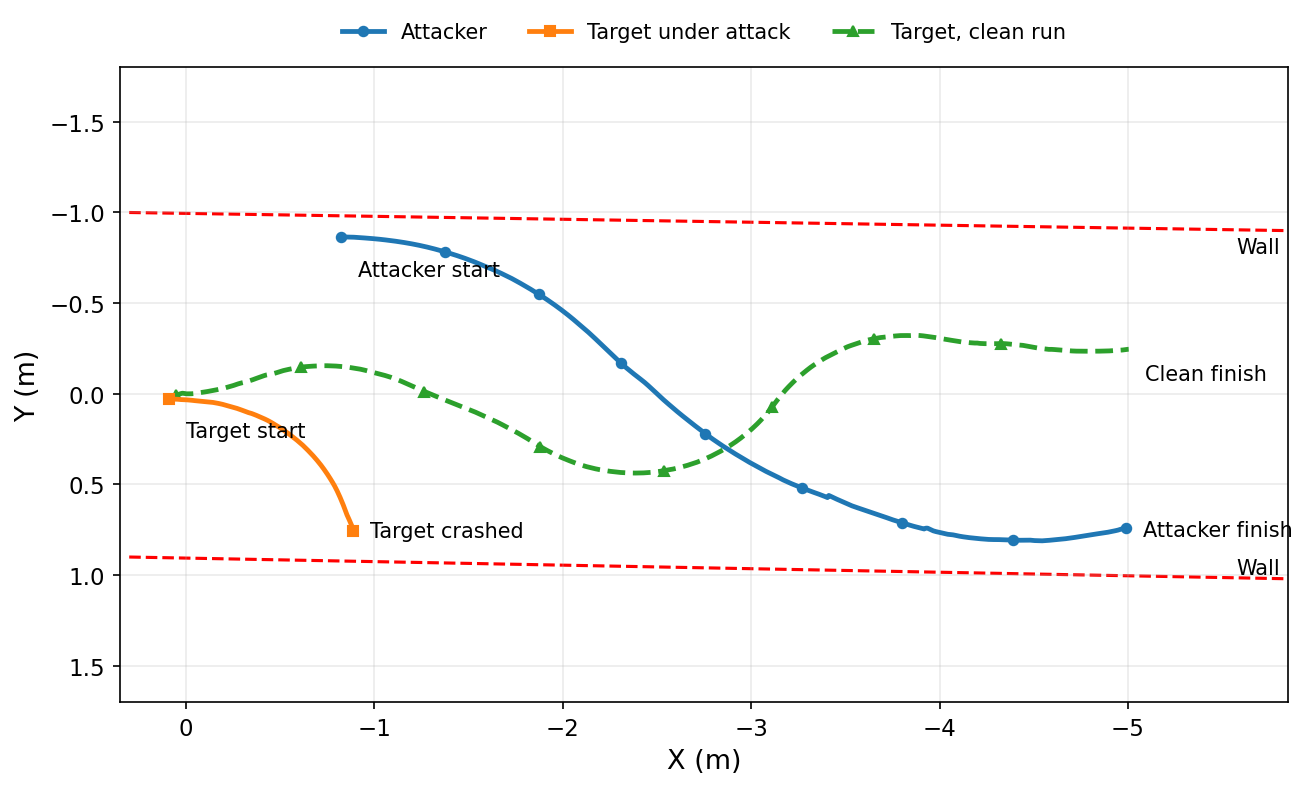

In [40]:
def marker_spacing(segment: pd.DataFrame) -> int:
    """Choose a marker interval that produces roughly N markers."""
    return max(1, len(segment) // N_TRAJECTORY_MARKERS)


def get_endpoint(
    segment: pd.DataFrame,
    endpoint: str,
) -> tuple[float, float]:
    """Return the smoothed start or ending coordinate."""

    if endpoint == "start":
        row = segment.iloc[0]
    elif endpoint == "end":
        row = segment.iloc[-1]
    else:
        raise ValueError("endpoint must be 'start' or 'end'.")

    return float(row["x_plot"]), float(row["y_plot"])


fig, ax = plt.subplots(
    figsize=(8.6, 5.15),
    constrained_layout=True,
)

# Attacker from the successful attack recording.
ax.plot(
    crash_attacker["x_plot"],
    crash_attacker["y_plot"],
    label="Attacker",
    color="C0",
    linestyle="-",
    marker="o",
    markevery=marker_spacing(crash_attacker),
    markersize=4.5,
    zorder=5,
)

# Target trajectory during the attack.
# Only mark the start and crash location to avoid stacking markers
# while the target remains stationary against the wall.
ax.plot(
    crash_target["x_plot"],
    crash_target["y_plot"],
    label="Target under attack",
    color="C1",
    linestyle="-",
    marker="s",
    markevery=[0, len(crash_target) - 1],
    markersize=4.5,
    zorder=6,
)

# Clean target trajectory from run 004.
# The dashed line and triangle symbol distinguish it in color and grayscale.
ax.plot(
    clean_target["x_plot"],
    clean_target["y_plot"],
    label="Target, clean run",
    color="C2",
    linestyle="--",
    marker="^",
    markevery=marker_spacing(clean_target),
    markersize=5.0,
    zorder=4,
)

# Corridor walls.
ax.plot(
    WALL_X,
    UPPER_WALL_Y,
    color="red",
    linestyle="--",
    linewidth=1.5,
    zorder=1,
)

ax.plot(
    WALL_X,
    LOWER_WALL_Y,
    color="red",
    linestyle="--",
    linewidth=1.5,
    zorder=1,
)


def annotate_endpoint(
    segment: pd.DataFrame,
    endpoint: str,
    text: str,
    offset: tuple[int, int],
) -> None:
    x, y = get_endpoint(segment, endpoint)

    ax.annotate(
        text,
        xy=(x, y),
        xytext=offset,
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        zorder=10,
    )


annotate_endpoint(
    crash_attacker,
    "start",
    "Attacker start",
    (8, -16),
)

annotate_endpoint(
    crash_attacker,
    "end",
    "Attacker finish",
    (8, -1),
)

annotate_endpoint(
    crash_target,
    "start",
    "Target start",
    (8, -15),
)

annotate_endpoint(
    crash_target,
    "end",
    "Target crashed",
    (8, 0),
)

annotate_endpoint(
    clean_target,
    "end",
    "Clean finish",
    (8, -12),
)

# Wall labels.
ax.annotate(
    "Wall",
    xy=(WALL_X[-1], UPPER_WALL_Y[-1]),
    xytext=(-4, -8),
    textcoords="offset points",
    ha="right",
    va="center",
    fontsize=10,
)

ax.annotate(
    "Wall",
    xy=(WALL_X[-1], LOWER_WALL_Y[-1]),
    xytext=(-4, 5),
    textcoords="offset points",
    ha="right",
    va="center",
    fontsize=10,
)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

# These descending limits reproduce the coordinate orientation
# used by the existing trajectory figure.
ax.set_xlim(*X_LIMITS)
ax.set_ylim(*Y_LIMITS)

ax.tick_params(axis="both", which="major")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
)

fig.savefig(
    OUT_DIR / f"{OUTPUT_STEM}.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / f"{OUTPUT_STEM}.png",
    bbox_inches="tight",
    dpi=600,
)

plt.show()